In [1]:
import torch
import numpy as np
import random
import os

from transformer_sac.config import *
from transformer_sac.data_loader import load_stocks
from transformer_sac.sac_trainer import SACTrainer
from transformer_sac.backtest import backtest, plot_equity, compute_buyhold_equity

print("Device:", DEVICE)

Device: cuda


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Seed fixed.")

Seed fixed.


In [3]:
train_states, train_prices = load_stocks(mode="train")
val_states, val_prices     = load_stocks(mode="val")
test_states, test_prices   = load_stocks(mode="test")

print("Train files:", len(train_states))
print("Val files:", len(val_states))
print("Test files:", len(test_states))

Train files: 10
Val files: 10
Test files: 10


In [4]:
trainer = SACTrainer()
print("Models initialized.")

Models initialized.


In [5]:
tickers = []

for file in sorted(os.listdir(DATA_FOLDER)):
    if file.endswith(".csv"):
        ticker = file.replace(".csv", "")
        tickers.append(ticker)

print(tickers)

['AAPL', 'AMD', 'AMZN', 'CSCO', 'GOOGL', 'INTC', 'META', 'MSFT', 'NVDA', 'TSLA']


In [6]:
trainer.train(
    train_states=train_states,
    train_prices=train_prices,
    tickers=tickers,
    val_states=val_states,
    val_prices=val_prices
)

Training Started
Episode 1/30
  MSFT       Final Value: 0.6131
    Action 0:  31.8%
    Action 1:  34.4%
    Action 2:  33.8%
  CSCO       Final Value: 0.5703
    Action 0:  31.5%
    Action 1:  36.8%
    Action 2:  31.7%
  AMZN       Final Value: 0.9975
    Action 0:  35.3%
    Action 1:  32.2%
    Action 2:  32.5%
  NVDA       Final Value: 0.9563
    Action 0:  35.3%
    Action 1:  30.9%
    Action 2:  33.8%
  INTC       Final Value: 0.7933
    Action 0:  33.8%
    Action 1:  32.6%
    Action 2:  33.6%
  META       Final Value: 1.4477
    Action 0:  31.3%
    Action 1:  31.2%
    Action 2:  37.5%
  TSLA       Final Value: 0.9629
    Action 0:  32.8%
    Action 1:  29.6%
    Action 2:  37.6%
  GOOGL      Final Value: 0.7907
    Action 0:  36.3%
    Action 1:  33.2%
    Action 2:  30.4%
  AAPL       Final Value: 1.0488
    Action 0:  34.4%
    Action 1:  33.2%
    Action 2:  32.3%
  AMD        Final Value: 0.7451
    Action 0:  41.5%
    Action 1:  27.4%
    Action 2:  31.0%
Average fi

In [7]:
best_model = SACTrainer()

best_model.actor.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
)

best_model.actor.to(DEVICE)
best_model.actor.eval()

print("Best model loaded.")

Best model loaded.


Average Return: 34.7139%
AAPL
------------------------------------------------------------
Total Return: 30.5793%
Win Rate:     27.36%
Final Value:  130579.296875

Action Distribution:
  ALLOC_0    Count:  226 |  53.30%
  ALLOC_35   Count:   10 |   2.36%
  ALLOC_70   Count:  188 |  44.34%


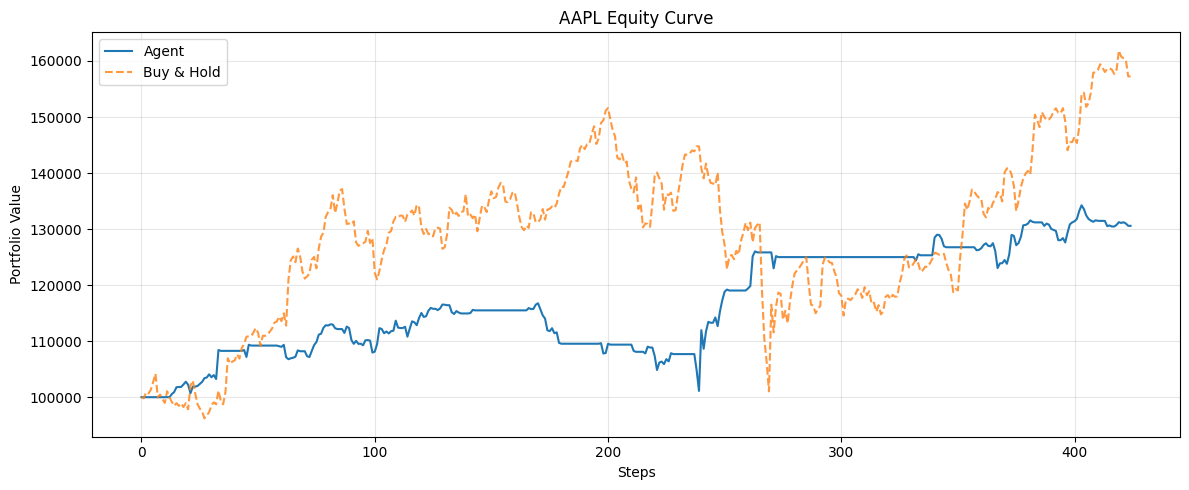

AMD
------------------------------------------------------------
Total Return: 60.1000%
Win Rate:     28.54%
Final Value:  160099.968750

Action Distribution:
  ALLOC_0    Count:  200 |  47.17%
  ALLOC_35   Count:    0 |   0.00%
  ALLOC_70   Count:  224 |  52.83%


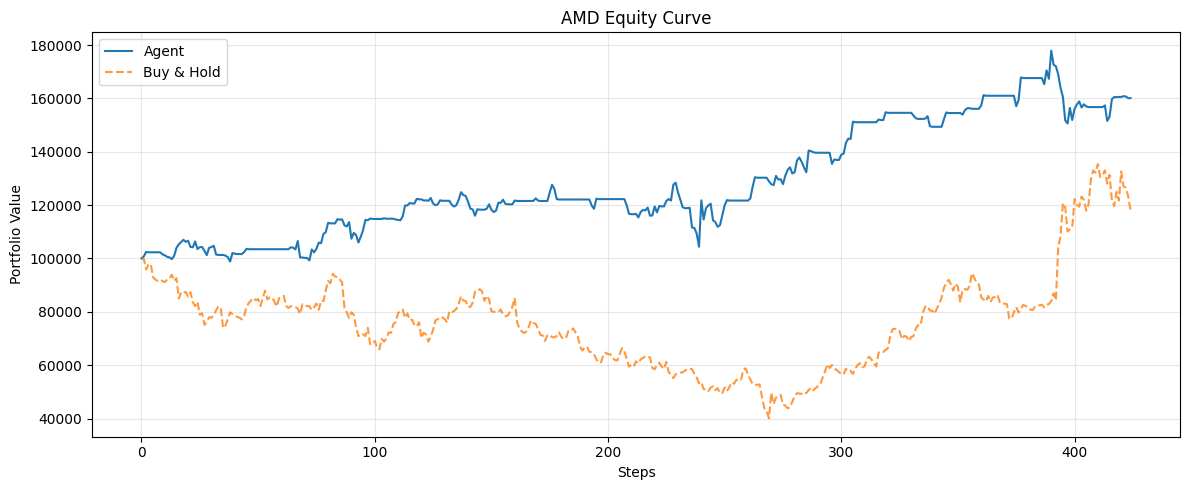

AMZN
------------------------------------------------------------
Total Return: 16.8860%
Win Rate:     21.93%
Final Value:  116885.984375

Action Distribution:
  ALLOC_0    Count:  245 |  57.78%
  ALLOC_35   Count:    5 |   1.18%
  ALLOC_70   Count:  174 |  41.04%


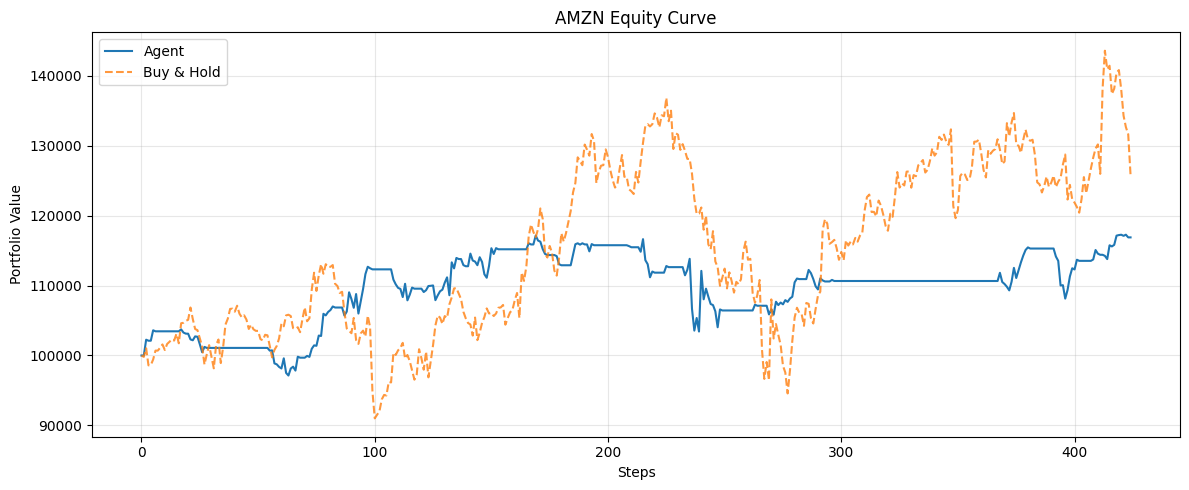

CSCO
------------------------------------------------------------
Total Return: 20.9269%
Win Rate:     22.64%
Final Value:  120926.890625

Action Distribution:
  ALLOC_0    Count:  237 |  55.90%
  ALLOC_35   Count:   22 |   5.19%
  ALLOC_70   Count:  165 |  38.92%


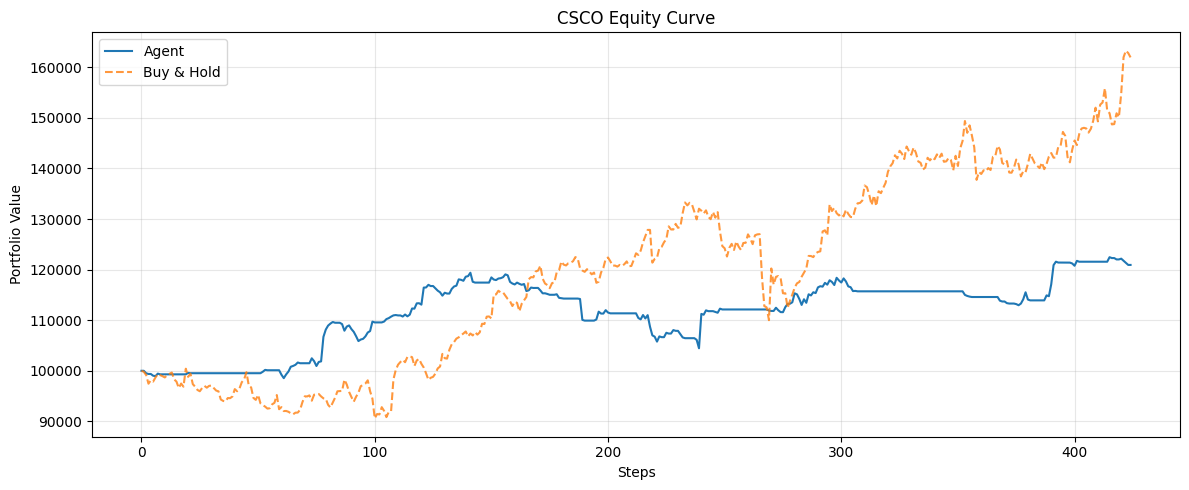

GOOGL
------------------------------------------------------------
Total Return: 15.4452%
Win Rate:     29.48%
Final Value:  115445.218750

Action Distribution:
  ALLOC_0    Count:  197 |  46.46%
  ALLOC_35   Count:    8 |   1.89%
  ALLOC_70   Count:  219 |  51.65%


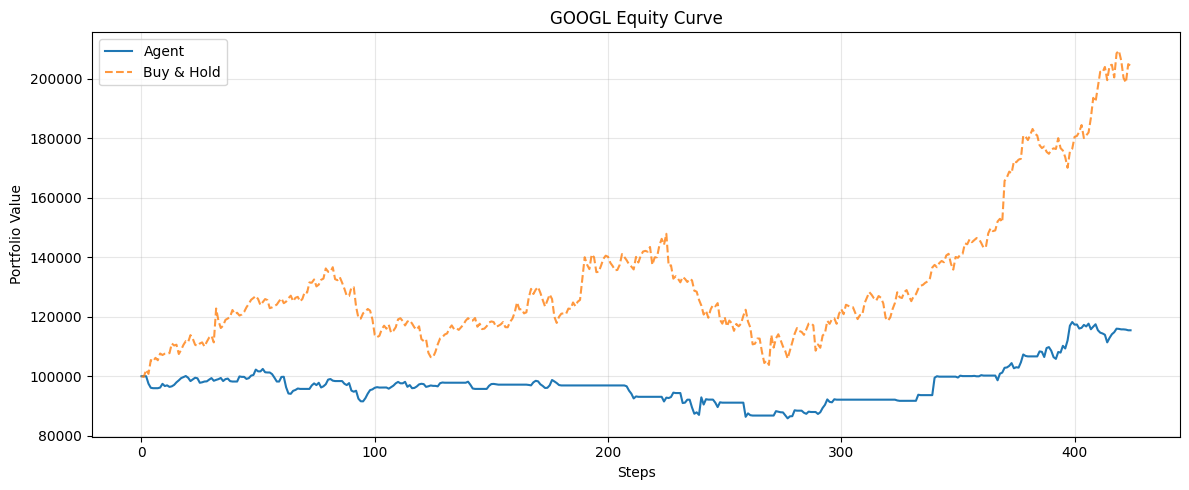

INTC
------------------------------------------------------------
Total Return: 32.0847%
Win Rate:     28.30%
Final Value:  132084.656250

Action Distribution:
  ALLOC_0    Count:  196 |  46.23%
  ALLOC_35   Count:    2 |   0.47%
  ALLOC_70   Count:  226 |  53.30%


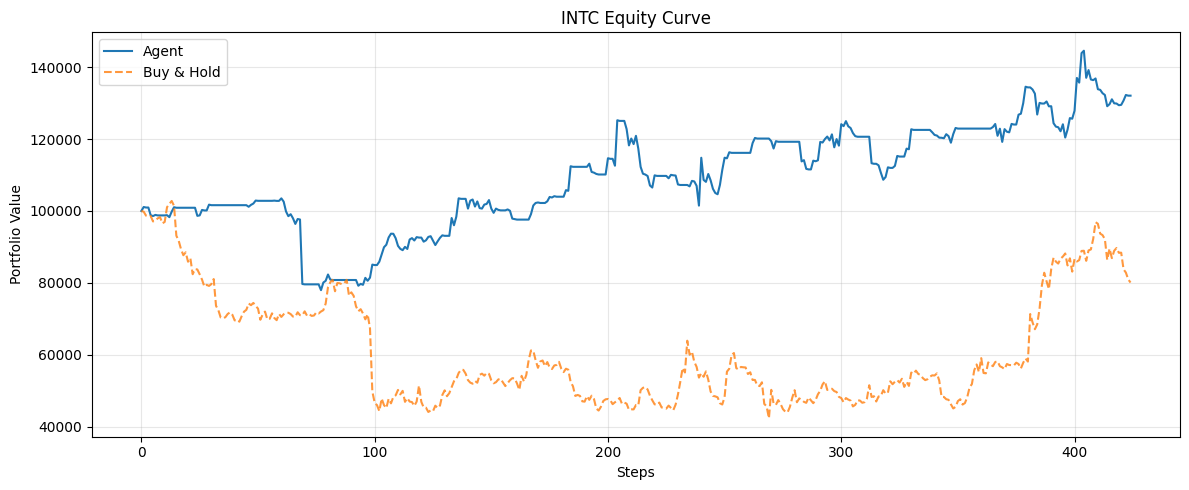

META
------------------------------------------------------------
Total Return: 8.2038%
Win Rate:     20.52%
Final Value:  108203.828125

Action Distribution:
  ALLOC_0    Count:  243 |  57.31%
  ALLOC_35   Count:    4 |   0.94%
  ALLOC_70   Count:  177 |  41.75%


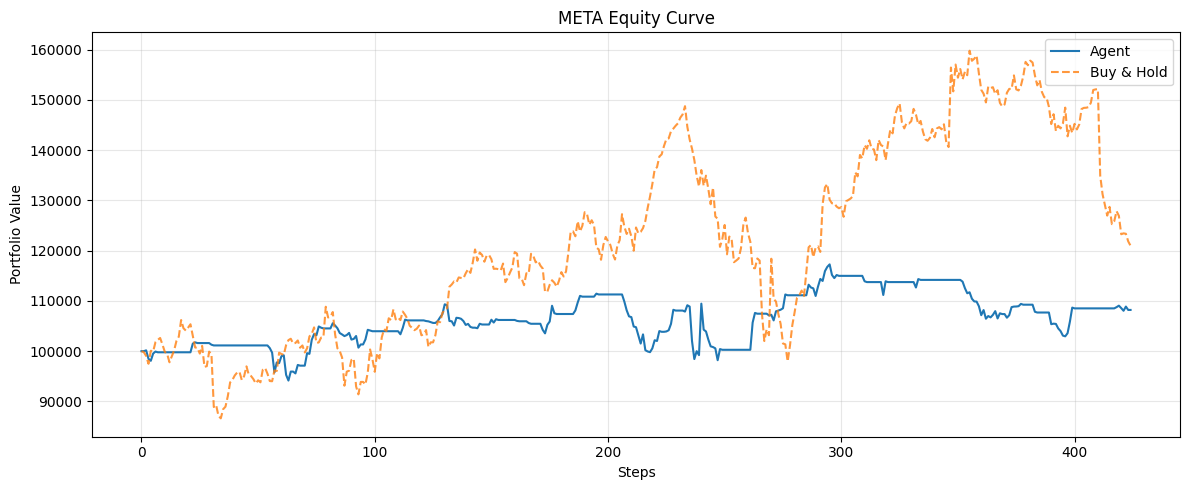

MSFT
------------------------------------------------------------
Total Return: -9.4496%
Win Rate:     24.06%
Final Value:  90550.382812

Action Distribution:
  ALLOC_0    Count:  226 |  53.30%
  ALLOC_35   Count:   18 |   4.25%
  ALLOC_70   Count:  180 |  42.45%


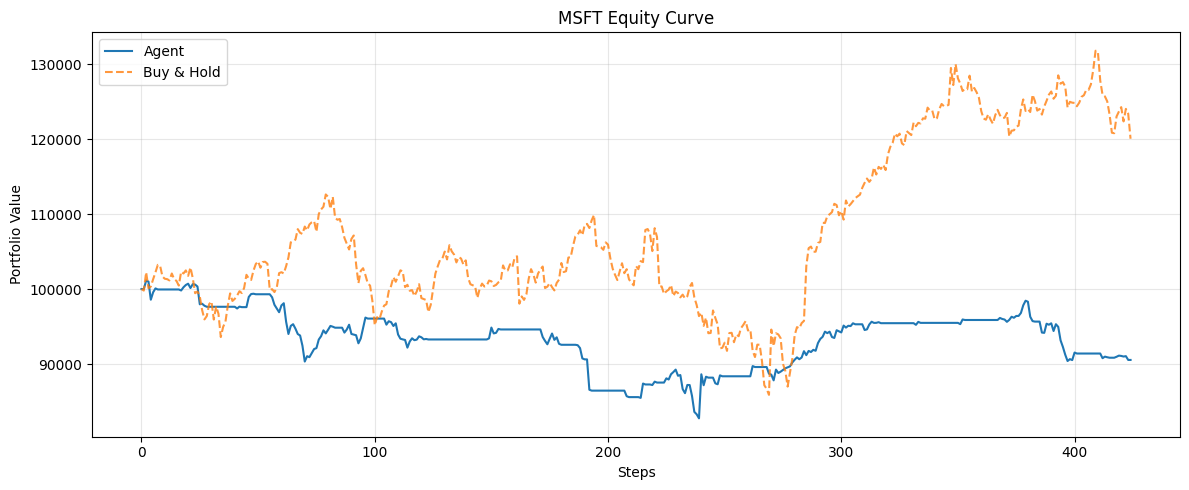

NVDA
------------------------------------------------------------
Total Return: 102.8879%
Win Rate:     33.25%
Final Value:  202887.890625

Action Distribution:
  ALLOC_0    Count:  182 |  42.92%
  ALLOC_35   Count:    2 |   0.47%
  ALLOC_70   Count:  240 |  56.60%


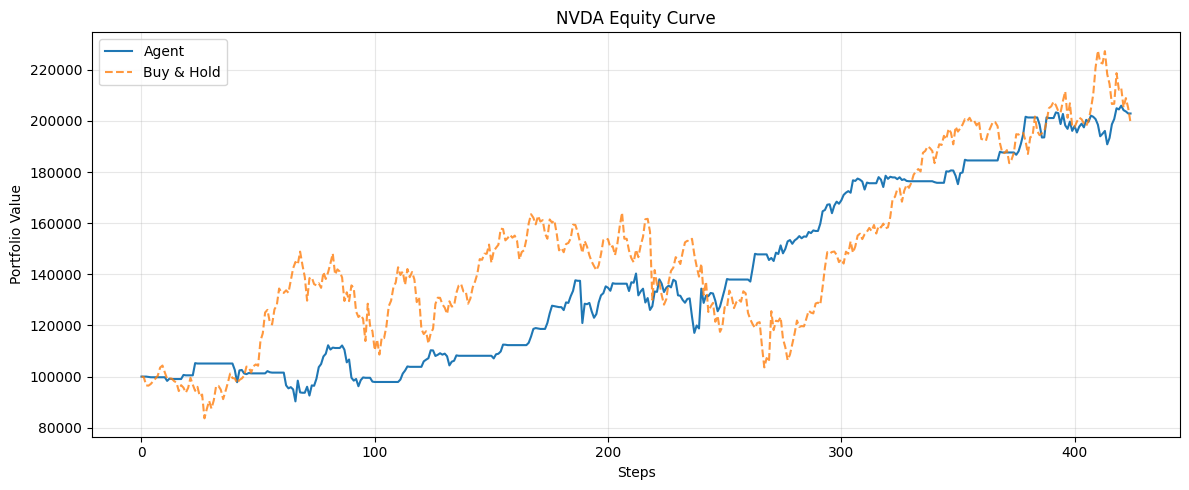

TSLA
------------------------------------------------------------
Total Return: 69.4753%
Win Rate:     26.65%
Final Value:  169475.296875

Action Distribution:
  ALLOC_0    Count:  210 |  49.53%
  ALLOC_35   Count:    0 |   0.00%
  ALLOC_70   Count:  214 |  50.47%


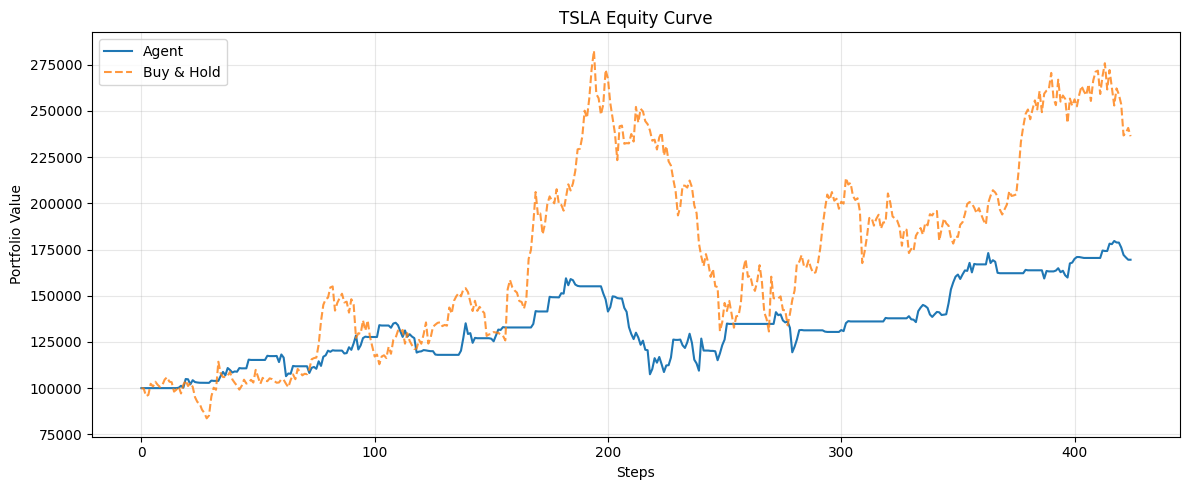

In [8]:
results_best_model = backtest(
    best_model,
    test_states,
    test_prices,
    tickers=tickers,
    steps_per_day=1
)

avg_return = sum(m['Total Return (%)'] for m in results_best_model.values()) / len(results_best_model)
print(f"Average Return: {avg_return:.4f}%")

for i, (ticker, metrics) in enumerate(results_best_model.items()):

    print("="*60)
    print(ticker)
    print("-"*60)

    print(f"Total Return: {metrics['Total Return (%)']:.4f}%")
    print(f"Win Rate:     {metrics['Win Rate (%)']:.2f}%")
    print(f"Final Value:  {metrics['Final Value']:.6f}")

    print("\nAction Distribution:")
    for action_name, stats in metrics["Action Distribution"].items():
        print(
            f"  {action_name:<10} "
            f"Count: {stats['count']:>4} | "
            f"{stats['percentage']:>6.2f}%"
        )

    print("="*60)

    #Buy & Hold Benchmark
    bh_equity = compute_buyhold_equity(test_prices[i])

    # Đảm bảo 2 curve cùng length
    min_len = min(len(metrics["Equity Curve"]), len(bh_equity))

    plot_equity(
        metrics["Equity Curve"][:min_len],
        title=f"{ticker} Equity Curve",
        benchmark=bh_equity[:min_len]
    )